# Apple Financial Health Index — Forecasting with ARIMAX & LSTM
### An end-to-end financial time series forecasting pipeline

**Author:** [Your Name]  
**Dataset Period:** June 2010 — April 2025  
**Last Updated:** 2025

---

**Objective:**  
Build a Financial Health Index (FHI) for Apple Inc. using key financial ratios, then forecast it using ARIMAX and LSTM models enriched with macroeconomic indicators, commodity prices and news sentiment.

**Data Sources:**
| Dataset | Source | Frequency |
|---------|--------|-----------|
| Apple Financial Ratios | Macrotrends | Quarterly (monthly forward-filled) |
| CPI — Consumer Price Index | FRED | Monthly |
| WTI Crude Oil Price | FRED | Monthly |
| Copper Price | FRED | Monthly |
| US GDP | FRED | Quarterly (monthly resampled) |
| Federal Funds Rate | FRED | Monthly |
| NYT Apple News Articles | New York Times API | Daily (monthly aggregated) |

**Pipeline:**  
`Load → Clean → Merge → Split → Outlier Treatment → Scale → FHI → Visualise → Model → Explain → Compare`

---
## Section 1 — Imports & Setup

In [11]:
!pip install optuna


In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Machine Learning & Statistics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Hyperparameter Optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Explainability
import shap
import joblib

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## Section 2 — Data Loading

All 7 datasets loaded as-is with no modifications.

In [13]:
# Apple Financial Ratios
apple    = pd.read_csv('/content/Apples Financial Data 2010 - 2025.csv')

# Macroeconomic & Commodity Data (FRED)
cpi      = pd.read_csv('/content/USA CPI 2010 - 2025.csv')
oil      = pd.read_csv('/content/USA Crude Oil 2010 - 2025 (1).csv')
copper   = pd.read_csv('/content/USA Copper prices 2010 - 2025.csv')
gdp      = pd.read_csv('/content/USA GDP 2010 - 2025.csv')
fedfunds = pd.read_csv('/content/USA Fed Funds 2010 - 2025 .csv')

# News Articles for Sentiment Analysis
news     = pd.read_csv('/content/nyt_apple_related_news.csv')

print("✓ All 7 datasets loaded successfully!")

✓ All 7 datasets loaded successfully!


---
## Section 3 — Cleaning Each Dataset

For each dataset:
- Convert dates to datetime and standardise to 1st of month (`YYYY-MM-01`)
- Filter to common date range: **2010-06-01 → 2025-04-01**
- Handle NaNs where applicable
- One inspection print after cleaning — no repetition

> **Note on Apple data:** Financial ratios are reported quarterly (every 3 months).
> Macrotrends forward-fills each quarter's value across 3 months, so the dataset
> appears monthly but is quarterly in nature. This is standard for financial ratio data.

### 3.1 — Apple Financial Data

In [14]:
apple['Date'] = pd.to_datetime(apple['Date']).dt.to_period('M').dt.to_timestamp()
apple.set_index('Date', inplace=True)
apple = apple.loc['2010-06-01':'2025-04-01']

print(f"Apple → Shape: {apple.shape} | Range: {apple.index.min().date()} → {apple.index.max().date()} | NaNs: {apple.isnull().sum().sum()}")
display(apple.head(3))

Apple → Shape: (179, 23) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,Stock Price,TTM Sales per Share,Price to Sales Ratio,TTM Net EPS,PE Ratio,TTM Net Income (ROA),Total Assets,Return on Assets,TTM Net Income (ROI),LT Investments & Debt,...,Return on Equity,Current Assets - Inventory,Current Liabilities,Quick Ratio,Current Assets,Current Ratio,Long Term Debt,Debt to Equity Ratio,Total Liabilities,Total Revenue
Date,,,,,,,,,,,,,,,,,,,,,
2010-06-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,32.66,35.09,15.61,2.25,36.03,2.31,21.61,0.5,21614.0,15700.0
2010-07-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,32.66,35.09,15.61,2.25,36.03,2.31,21.61,0.5,21614.0,15700.0
2010-08-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,32.66,35.09,15.61,2.25,36.03,2.31,21.61,0.5,21614.0,15700.0


### 3.2 — CPI (Consumer Price Index)

In [15]:
cpi['observation_date'] = pd.to_datetime(cpi['observation_date']).dt.to_period('M').dt.to_timestamp()
cpi.set_index('observation_date', inplace=True)
cpi.index.name = 'Date'
cpi = cpi.loc['2010-06-01':'2025-04-01']

print(f"CPI → Shape: {cpi.shape} | Range: {cpi.index.min().date()} → {cpi.index.max().date()} | NaNs: {cpi.isnull().sum().sum()}")
display(cpi.head(3))

CPI → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,CPIAUCSL
Date,
2010-06-01,217.199
2010-07-01,217.605
2010-08-01,217.923


### 3.3 — WTI Crude Oil

In [16]:
oil['observation_date'] = pd.to_datetime(oil['observation_date']).dt.to_period('M').dt.to_timestamp()
oil.set_index('observation_date', inplace=True)
oil.index.name = 'Date'
oil = oil.loc['2010-06-01':'2025-04-01']

print(f"Oil → Shape: {oil.shape} | Range: {oil.index.min().date()} → {oil.index.max().date()} | NaNs: {oil.isnull().sum().sum()}")
display(oil.head(3))

Oil → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,WTISPLC
Date,
2010-06-01,75.35
2010-07-01,76.37
2010-08-01,76.82


### 3.4 — Copper Price

In [17]:
copper['observation_date'] = pd.to_datetime(copper['observation_date']).dt.to_period('M').dt.to_timestamp()
copper.set_index('observation_date', inplace=True)
copper.index.name = 'Date'
copper = copper.loc['2010-06-01':'2025-04-01']

print(f"Copper → Shape: {copper.shape} | Range: {copper.index.min().date()} → {copper.index.max().date()} | NaNs: {copper.isnull().sum().sum()}")
display(copper.head(3))

Copper → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,PCOPPUSDM
Date,
2010-06-01,6501.500000
2010-07-01,6750.568182
2010-08-01,7302.666667


### 3.5 — GDP (Quarterly → Monthly)

In [18]:
gdp['observation_date'] = pd.to_datetime(gdp['observation_date']).dt.to_period('M').dt.to_timestamp()
gdp.set_index('observation_date', inplace=True)
gdp.index.name = 'Date'

# GDP is reported quarterly — resample to monthly using forward fill
gdp = gdp.resample('MS').ffill()
gdp = gdp.loc['2010-06-01':'2025-04-01']

print(f"GDP → Shape: {gdp.shape} | Range: {gdp.index.min().date()} → {gdp.index.max().date()} | NaNs: {gdp.isnull().sum().sum()}")
display(gdp.head(6))

GDP → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,GDP
Date,
2010-06-01,14980.193
2010-07-01,15141.607
2010-08-01,15141.607
2010-09-01,15141.607
2010-10-01,15309.474
2010-11-01,15309.474


### 3.6 — Federal Funds Rate

In [19]:
fedfunds['observation_date'] = pd.to_datetime(fedfunds['observation_date']).dt.to_period('M').dt.to_timestamp()
fedfunds.set_index('observation_date', inplace=True)
fedfunds.index.name = 'Date'
fedfunds = fedfunds.loc['2010-06-01':'2025-04-01']

print(f"Fed Funds → Shape: {fedfunds.shape} | Range: {fedfunds.index.min().date()} → {fedfunds.index.max().date()} | NaNs: {fedfunds.isnull().sum().sum()}")
display(fedfunds.head(3))

Fed Funds → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,FEDFUNDS
Date,
2010-06-01,0.18
2010-07-01,0.18
2010-08-01,0.19


### 3.7 — News Sentiment (FinBERT)

In [20]:
!pip install transformers torch --quiet
print('✓ transformers and torch ready')

✓ transformers and torch ready


In [21]:
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Filter to common date range
news['pub_date'] = pd.to_datetime(news['pub_date'])
news = news[news['pub_date'] >= '2010-06-01'].copy()

# Handle missing snippets
news['snippet'] = news['snippet'].fillna('')

# Clean and combine headline + snippet for richer context
def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

news['text'] = (news['headline'] + '. ' + news['snippet']).apply(clean_text)
print(f"News → {len(news)} articles ready for sentiment scoring")

News → 1069 articles ready for sentiment scoring


In [22]:
# Load FinBERT — financial domain BERT model
model_name = 'ProsusAI/finbert'
tokenizer  = AutoTokenizer.from_pretrained(model_name)
finbert    = AutoModelForSequenceClassification.from_pretrained(model_name)
finbert.eval()
print("✓ FinBERT loaded")

def get_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        scores = torch.nn.functional.softmax(finbert(**inputs).logits, dim=-1)[0]
    labels = ['negative', 'neutral', 'positive']
    return {
        'sentiment'      : labels[scores.argmax().item()],
        'score_positive' : float(scores[2]),
        'score_neutral'  : float(scores[1]),
        'score_negative' : float(scores[0])
    }

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ FinBERT loaded


In [23]:
print(f"Scoring {len(news)} articles with FinBERT...")
sentiment_cols = news['text'].apply(get_sentiment).apply(pd.Series)
news = news.join(sentiment_cols)

# Derive single sentiment score from predicted label
def final_score(row):
    if row['sentiment'] == 'positive' : return row['score_positive']
    elif row['sentiment'] == 'negative': return row['score_negative']
    else                               : return row['score_neutral']

news['sentiment_score'] = news.apply(final_score, axis=1)

print(f"✓ Scoring complete")
print(f"Sentiment distribution:\n{news['sentiment'].value_counts().to_string()}")

Scoring 1069 articles with FinBERT...
✓ Scoring complete
Sentiment distribution:
sentiment
positive    601
neutral     351
negative    117


In [24]:
# Aggregate to monthly average sentiment score
news['Date'] = news['pub_date'].dt.to_period('M').dt.to_timestamp()
sentiment_monthly = news.groupby('Date')['sentiment_score'].mean().to_frame()

# Reindex to full monthly range and forward fill gaps
full_idx = pd.date_range('2010-06-01', '2025-04-01', freq='MS')
sentiment_monthly = sentiment_monthly.reindex(full_idx)
sentiment_monthly.index.name = 'Date'
sentiment_monthly = sentiment_monthly.ffill()

# Fill any remaining leading NaNs with the first available value
first_valid = sentiment_monthly['sentiment_score'].first_valid_index()
sentiment_monthly.loc[:first_valid, 'sentiment_score'] = sentiment_monthly.loc[first_valid, 'sentiment_score']

print(f"Sentiment → Shape: {sentiment_monthly.shape} | Range: {sentiment_monthly.index.min().date()} → {sentiment_monthly.index.max().date()} | NaNs: {sentiment_monthly.isnull().sum().sum()}")
display(sentiment_monthly.head(3))

Sentiment → Shape: (179, 1) | Range: 2010-06-01 → 2025-04-01 | NaNs: 0


,sentiment_score
Date,
2010-06-01,0.657418
2010-07-01,0.657418
2010-08-01,0.657418


---
## Section 4 — Alignment Check

Single check to confirm all 7 datasets are aligned before merging.

In [25]:
datasets = {
    'Apple'    : apple,
    'CPI'      : cpi,
    'Oil'      : oil,
    'Copper'   : copper,
    'GDP'      : gdp,
    'FedFunds' : fedfunds,
    'Sentiment': sentiment_monthly
}

print(f"{'Dataset':<12} {'Rows':<8} {'Start':<14} {'End':<14} {'NaNs'}")
print("-" * 58)
for name, df in datasets.items():
    print(f"{name:<12} {len(df):<8} {str(df.index.min().date()):<14} {str(df.index.max().date()):<14} {df.isnull().sum().sum()}")

print("\nIndex alignment vs Apple:")
for name, df in datasets.items():
    if name == 'Apple': continue
    print(f"  {name:<12}: {'✓ Aligned' if df.index.equals(apple.index) else '✗ MISMATCH'}")

Dataset      Rows     Start          End            NaNs
----------------------------------------------------------
Apple        179      2010-06-01     2025-04-01     0
CPI          179      2010-06-01     2025-04-01     0
Oil          179      2010-06-01     2025-04-01     0
Copper       179      2010-06-01     2025-04-01     0
GDP          179      2010-06-01     2025-04-01     0
FedFunds     179      2010-06-01     2025-04-01     0
Sentiment    179      2010-06-01     2025-04-01     0

Index alignment vs Apple:
  CPI         : ✓ Aligned
  Oil         : ✓ Aligned
  Copper      : ✓ Aligned
  GDP         : ✓ Aligned
  FedFunds    : ✓ Aligned
  Sentiment   : ✓ Aligned


---
## Section 5 — Merging

All datasets cleaned and aligned on the same monthly index. Merging into one complete dataset.

In [26]:
combined = apple.copy()
combined = combined.join(cpi,               how='inner')
combined = combined.join(oil,               how='inner')
combined = combined.join(copper,            how='inner')
combined = combined.join(gdp,               how='inner')
combined = combined.join(fedfunds,          how='inner')
combined = combined.join(sentiment_monthly, how='inner')

# Forward fill any residual NaNs — no backward fill to preserve temporal order
combined = combined.ffill()

print(f"✓ Merged dataset")
print(f"  Shape     : {combined.shape}")
print(f"  Date range: {combined.index.min().date()} → {combined.index.max().date()}")
print(f"  NaNs      : {combined.isnull().sum().sum()}")
print(f"  Columns   : {list(combined.columns)}")

✓ Merged dataset
  Shape     : (179, 29)
  Date range: 2010-06-01 → 2025-04-01
  NaNs      : 0
  Columns   : ['Stock Price', 'TTM Sales per Share', 'Price to Sales Ratio', 'TTM Net EPS', 'PE Ratio', 'TTM Net Income (ROA)', 'Total Assets', 'Return on Assets', 'TTM Net Income (ROI)', 'LT Investments & Debt', 'Return on Investment', 'TTM Net Income (ROE)', "Shareholder's Equity", 'Return on Equity', 'Current Assets - Inventory', 'Current Liabilities', 'Quick Ratio', 'Current Assets', 'Current Ratio', 'Long Term Debt', 'Debt to Equity Ratio', 'Total Liabilities', 'Total Revenue', 'CPIAUCSL', 'WTISPLC', 'PCOPPUSDM', 'GDP', 'FEDFUNDS', 'sentiment_score']


In [27]:
display(combined.head(3))
display(combined.tail(3))

,Stock Price,TTM Sales per Share,Price to Sales Ratio,TTM Net EPS,PE Ratio,TTM Net Income (ROA),Total Assets,Return on Assets,TTM Net Income (ROI),LT Investments & Debt,...,Long Term Debt,Debt to Equity Ratio,Total Liabilities,Total Revenue,CPIAUCSL,WTISPLC,PCOPPUSDM,GDP,FEDFUNDS,sentiment_score
Date,,,,,,,,,,,,,,,,,,,,,
2010-06-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,21.61,0.5,21614.0,15700.0,217.199,75.35,6501.500000,14980.193,0.18,0.657418
2010-07-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,21.61,0.5,21614.0,15700.0,217.605,76.37,6750.568182,15141.607,0.18,0.657418
2010-08-01,7.56,2.22,3.41,0.44,17.17,12.24,64.73,21.93,16.62,140.31,...,21.61,0.5,21614.0,15700.0,217.923,76.82,7302.666667,15141.607,0.19,0.657418


,Stock Price,TTM Sales per Share,Price to Sales Ratio,TTM Net EPS,PE Ratio,TTM Net Income (ROA),Total Assets,Return on Assets,TTM Net Income (ROI),LT Investments & Debt,...,Long Term Debt,Debt to Equity Ratio,Total Liabilities,Total Revenue,CPIAUCSL,WTISPLC,PCOPPUSDM,GDP,FEDFUNDS,sentiment_score
Date,,,,,,,,,,,,,,,,,,,,,
2025-02-01,249.82,25.82,9.67,6.30,39.65,96.15,344.09,27.91,125.68,150.71,...,277.33,4.15,277327.0,124300.0,319.679,71.53,9330.975000,29962.047,4.33,0.752583
2025-03-01,221.84,26.29,8.44,6.42,34.55,97.29,331.23,28.37,127.36,145.36,...,264.44,3.96,264437.0,95359.0,319.785,68.24,9735.823333,29962.047,4.33,0.787991
2025-04-01,221.84,26.29,8.44,6.42,34.55,97.29,331.23,28.37,127.36,145.36,...,264.44,3.96,264437.0,95359.0,320.302,63.54,9172.695909,30331.117,4.33,0.846569


In [28]:
combined.to_csv('combined_raw.csv')
print("✓ Saved: combined_raw.csv")

✓ Saved: combined_raw.csv


---
## Section 6 — Train / Validation / Test Split

**The split is performed FIRST — before any outlier treatment or scaling.**

This is critical to prevent data leakage: if we scaled or treated outliers on the full
dataset first, future values would influence how we process past data.

Split ratio: **70% train | 15% validation | 15% test**  
Split type: **Time-based** (chronological order preserved — no shuffling)

In [29]:
# Define column groups
apple_cols = list(apple.columns)
macro_cols = ['CPIAUCSL', 'WTISPLC', 'PCOPPUSDM', 'GDP', 'FEDFUNDS', 'sentiment_score']
all_cols   = apple_cols + macro_cols

# Split on raw merged data — boundaries fixed for the entire pipeline
n         = len(combined)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = combined.iloc[:train_end]
val_raw   = combined.iloc[train_end:val_end]
test_raw  = combined.iloc[val_end:]

print(f"Total : {n} rows")
print(f"Train : {len(train_raw)} | {train_raw.index.min().date()} → {train_raw.index.max().date()}")
print(f"Val   : {len(val_raw)}   | {val_raw.index.min().date()} → {val_raw.index.max().date()}")
print(f"Test  : {len(test_raw)}  | {test_raw.index.min().date()} → {test_raw.index.max().date()}")
print(f"\nSplit boundaries are fixed and will not change for the rest of the pipeline.")

Total : 179 rows
Train : 125 | 2010-06-01 → 2020-10-01
Val   : 27   | 2020-11-01 → 2023-01-01
Test  : 27  | 2023-02-01 → 2025-04-01

Split boundaries are fixed and will not change for the rest of the pipeline.


In [30]:
# Outlier Treatment — IQR method on Apple financial columns only
# Macro data (CPI, Oil, Copper etc.) is kept as-is since extreme values carry real meaning

# IQR boundaries computed from training data only — no future information used
Q1  = train_raw[apple_cols].quantile(0.25)
Q3  = train_raw[apple_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

combined_clean = combined.copy()
total_replaced = 0

for col in apple_cols:
    mask = (
        (combined_clean[col] < lower_bound[col]) |
        (combined_clean[col] > upper_bound[col])
    )
    count = mask.sum()
    if count > 0:
        print(f"  {col}: {count} outlier(s) replaced")
        total_replaced += count
    combined_clean.loc[mask, col] = np.nan

# Forward fill only — backward fill not used as it would pull future values into the past
combined_clean[apple_cols] = combined_clean[apple_cols].ffill()
for col in apple_cols:
    first_valid = combined_clean[col].first_valid_index()
    if first_valid is not None:
        combined_clean.loc[:first_valid, col] = combined_clean.loc[first_valid, col]

print(f"\nTotal outliers replaced : {total_replaced}")
print(f"NaNs after fill         : {combined_clean.isnull().sum().sum()}")
print(f"Shape                   : {combined_clean.shape}")

  Stock Price: 59 outlier(s) replaced
  TTM Sales per Share: 44 outlier(s) replaced
  Price to Sales Ratio: 62 outlier(s) replaced
  TTM Net EPS: 50 outlier(s) replaced
  PE Ratio: 50 outlier(s) replaced
  TTM Net Income (ROA): 50 outlier(s) replaced
  TTM Net Income (ROI): 59 outlier(s) replaced
  Return on Investment: 3 outlier(s) replaced
  TTM Net Income (ROE): 50 outlier(s) replaced
  Return on Equity: 65 outlier(s) replaced
  Current Liabilities: 3 outlier(s) replaced
  Quick Ratio: 3 outlier(s) replaced
  Current Ratio: 3 outlier(s) replaced
  Debt to Equity Ratio: 47 outlier(s) replaced
  Total Revenue: 26 outlier(s) replaced

Total outliers replaced : 574
NaNs after fill         : 0
Shape                   : (179, 29)


---
## Section 7 — Scaling

**MinMaxScaler is fitted on the training set only.**

Fitting on the full dataset would allow future values to influence how past data
is scaled — a subtle but important form of data leakage.

In [31]:
# Use the same fixed split boundaries from Section 6
train_df = combined_clean.iloc[:train_end]
val_df   = combined_clean.iloc[train_end:val_end]
test_df  = combined_clean.iloc[val_end:]

# Fit scaler on training data only
scaler = MinMaxScaler()
scaler.fit(train_df[all_cols])

# Transform each split using training statistics
train_scaled = pd.DataFrame(
    scaler.transform(train_df[all_cols]),
    columns=all_cols, index=train_df.index
)
val_scaled = pd.DataFrame(
    scaler.transform(val_df[all_cols]),
    columns=all_cols, index=val_df.index
)
test_scaled = pd.DataFrame(
    scaler.transform(test_df[all_cols]),
    columns=all_cols, index=test_df.index
)

scaled_df = pd.concat([train_scaled, val_scaled, test_scaled])

print(f"Scaled DataFrame → Shape: {scaled_df.shape}")
print(f"Value range → Min: {scaled_df.min().min():.4f} | Max: {scaled_df.max().max():.4f}")
print("Note: Values outside [0,1] in val/test are expected — the scaler was fitted on train only.")
display(scaled_df.head(3))

Scaled DataFrame → Shape: (179, 29)
Value range → Min: -0.1919 | Max: 2.3911
Note: Values outside [0,1] in val/test are expected — the scaler was fitted on train only.


,Stock Price,TTM Sales per Share,Price to Sales Ratio,TTM Net EPS,PE Ratio,TTM Net Income (ROA),Total Assets,Return on Assets,TTM Net Income (ROI),LT Investments & Debt,...,Long Term Debt,Debt to Equity Ratio,Total Liabilities,Total Revenue,CPIAUCSL,WTISPLC,PCOPPUSDM,GDP,FEDFUNDS,sentiment_score
Date,,,,,,,,,,,,,,,,,,,,,
2010-06-01,0.0,0.0,0.669604,0.0,0.622126,0.0,0.0,0.496933,0.0,0.029632,...,0.0,0.020339,0.0,0.0,0.000000,0.628944,0.375237,0.000000,0.054852,0.239112
2010-07-01,0.0,0.0,0.669604,0.0,0.622126,0.0,0.0,0.496933,0.0,0.029632,...,0.0,0.020339,0.0,0.0,0.009416,0.639855,0.421283,0.022771,0.054852,0.239112
2010-08-01,0.0,0.0,0.669604,0.0,0.622126,0.0,0.0,0.496933,0.0,0.029632,...,0.0,0.020339,0.0,0.0,0.016790,0.644668,0.523350,0.022771,0.059072,0.239112


---
## Section 8 — Financial Health Index (FHI)

The FHI is a **weighted composite score** built from 5 key financial ratios.
It serves as our forecasting target — a single number summarising Apple's financial health.

| Ratio | Weight | Rationale |
|-------|--------|-----------|
| Debt to Equity Ratio | 25% | Measures leverage and financial risk |
| Return on Equity | 25% | Measures profitability to shareholders |
| Return on Investment | 20% | Measures capital efficiency |
| Return on Assets | 20% | Measures how efficiently assets generate profit |
| Current Ratio | 10% | Measures short-term liquidity |

**Total = 100%** — computed on scaled (0–1) values so all ratios contribute fairly.

In [32]:
# Compute FHI as weighted sum of scaled financial ratios
weights = {
    'Debt to Equity Ratio': 0.25,
    'Return on Equity'    : 0.25,
    'Return on Investment': 0.20,
    'Return on Assets'    : 0.20,
    'Current Ratio'       : 0.10
}

scaled_df['fhi'] = sum(scaled_df[col] * w for col, w in weights.items())

print("FHI Statistics:")
print(scaled_df['fhi'].describe().round(4))

FHI Statistics:
count    179.0000
mean       0.5309
std        0.2638
min        0.1843
25%        0.3055
50%        0.4056
75%        0.8629
max        0.9412
Name: fhi, dtype: float64


In [33]:
# Log transform to stabilise variance and reduce skewness
# Small epsilon added to prevent log(0) for any zero values
epsilon = 1e-8
scaled_df['fhi_log'] = np.log(scaled_df['fhi'] + epsilon)

print("FHI Log Statistics:")
print(scaled_df['fhi_log'].describe().round(4))

FHI Log Statistics:
count    179.0000
mean      -0.7587
std        0.5049
min       -1.6910
25%       -1.1859
50%       -0.9025
75%       -0.1475
max       -0.0606
Name: fhi_log, dtype: float64


In [34]:
# Augmented Dickey-Fuller Test — checks if the series is stationary
# ARIMA and LSTM require stationary input for reliable forecasting
result = adfuller(scaled_df['fhi_log'].dropna())

print("ADF Stationarity Test on fhi_log:")
print(f"  ADF Statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.4f}")
print(f"  Critical Values:")
for key, val in result[4].items():
    print(f"    {key}: {val:.3f}")

if result[1] > 0.05:
    print("\n→ Series is NOT stationary. Applying first differencing.")
    scaled_df['fhi_log_diff'] = scaled_df['fhi_log'].diff()
    target_col = 'fhi_log_diff'
    diff_result = adfuller(scaled_df['fhi_log_diff'].dropna())
    print(f"  After differencing → p-value: {diff_result[1]:.4f}")
    if diff_result[1] <= 0.05:
        print("  → Differenced series IS stationary ✓")
else:
    print("\n→ Series IS stationary ✓")
    target_col = 'fhi_log'

print(f"\nTarget column for modelling: '{target_col}'")

ADF Stationarity Test on fhi_log:
  ADF Statistic : -0.9800
  p-value       : 0.7605
  Critical Values:
    1%: -3.468
    5%: -2.878
    10%: -2.576

→ Series is NOT stationary. Applying first differencing.
  After differencing → p-value: 0.0000
  → Differenced series IS stationary ✓

Target column for modelling: 'fhi_log_diff'


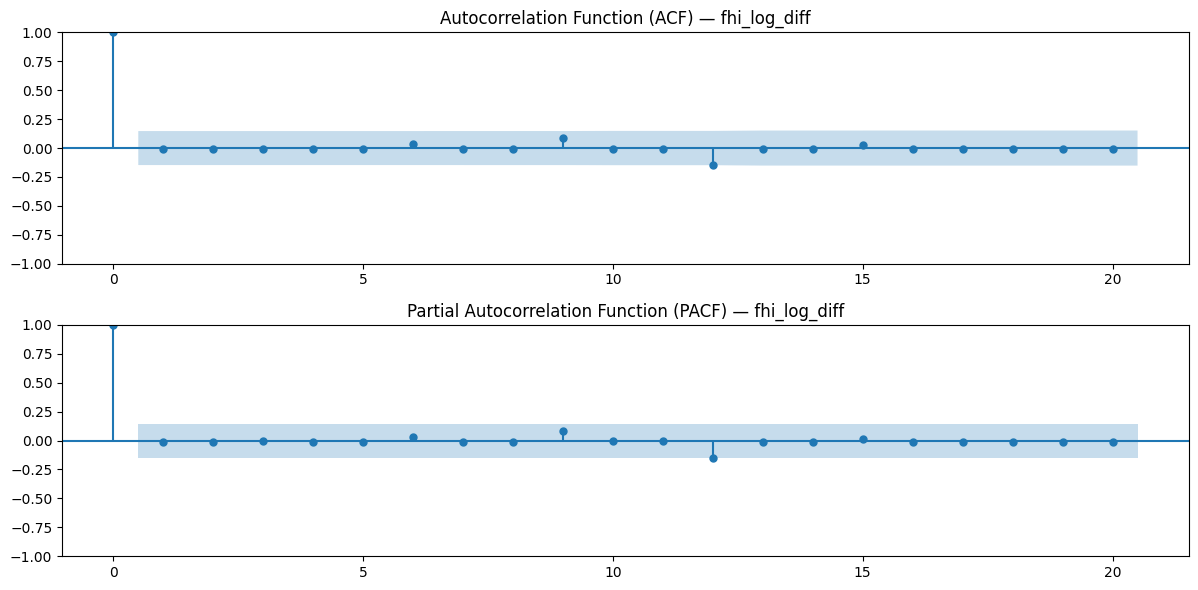

In [35]:
# ACF and PACF plots help determine the ARIMA order (p, q)
# These must be plotted on the stationary series
series_acf = scaled_df[target_col].dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(series_acf,  ax=axes[0], lags=20, title=f'Autocorrelation Function (ACF) — {target_col}')
plot_pacf(series_acf, ax=axes[1], lags=20, title=f'Partial Autocorrelation Function (PACF) — {target_col}')
plt.tight_layout()
plt.show()

In [36]:
scaled_df.to_csv('scaled_combined.csv')
print(f"✓ Saved: scaled_combined.csv")
print(f"  Shape  : {scaled_df.shape}")
print(f"  Columns: {list(scaled_df.columns)}")

✓ Saved: scaled_combined.csv
  Shape  : (179, 32)
  Columns: ['Stock Price', 'TTM Sales per Share', 'Price to Sales Ratio', 'TTM Net EPS', 'PE Ratio', 'TTM Net Income (ROA)', 'Total Assets', 'Return on Assets', 'TTM Net Income (ROI)', 'LT Investments & Debt', 'Return on Investment', 'TTM Net Income (ROE)', "Shareholder's Equity", 'Return on Equity', 'Current Assets - Inventory', 'Current Liabilities', 'Quick Ratio', 'Current Assets', 'Current Ratio', 'Long Term Debt', 'Debt to Equity Ratio', 'Total Liabilities', 'Total Revenue', 'CPIAUCSL', 'WTISPLC', 'PCOPPUSDM', 'GDP', 'FEDFUNDS', 'sentiment_score', 'fhi', 'fhi_log', 'fhi_log_diff']


---
## Section 9 — Visualisations

### 9.1 — Apple Financial Ratios Over Time

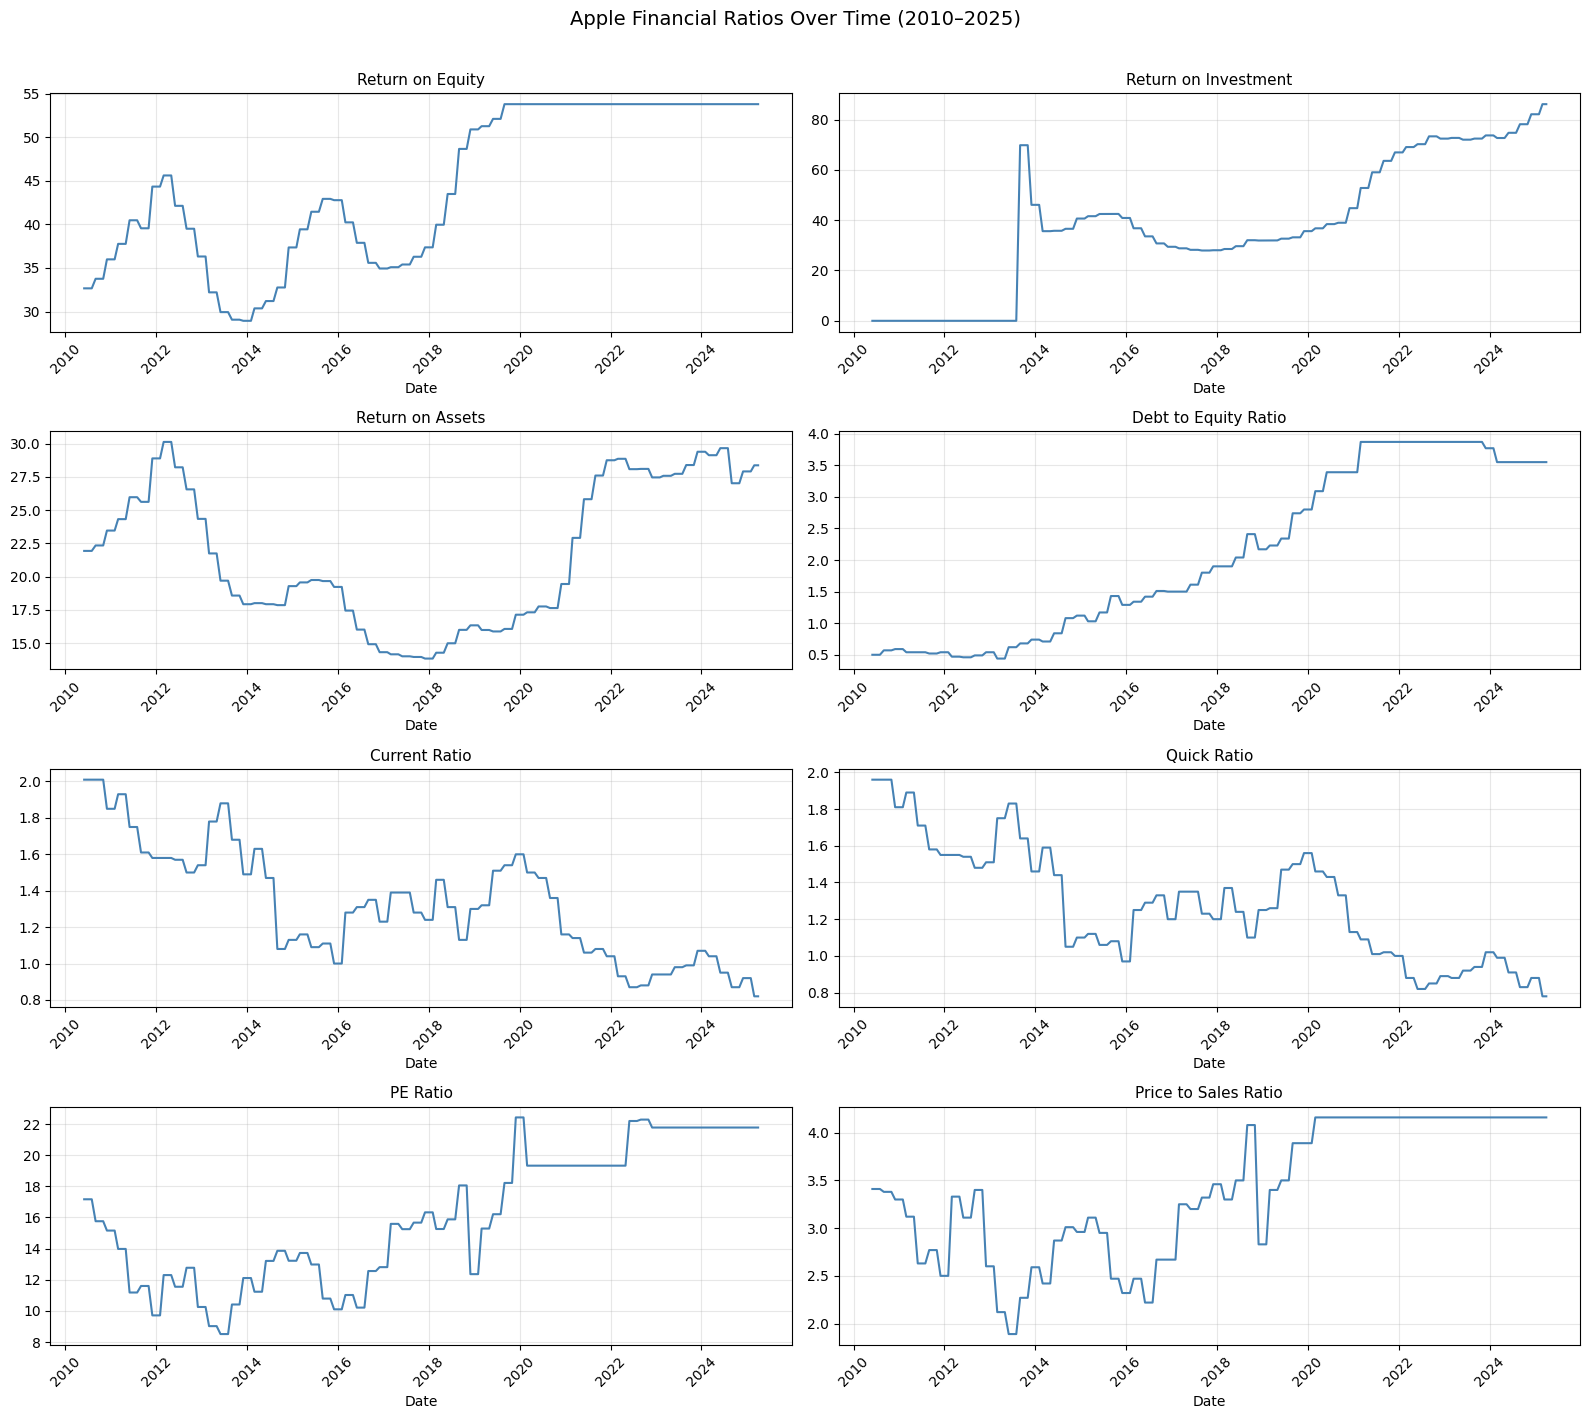

In [37]:
ratio_cols = [
    'Return on Equity', 'Return on Investment', 'Return on Assets',
    'Debt to Equity Ratio', 'Current Ratio', 'Quick Ratio',
    'PE Ratio', 'Price to Sales Ratio'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(ratio_cols):
    axes[i].plot(combined_clean.index, combined_clean[col], linewidth=1.5, color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Date')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Apple Financial Ratios Over Time (2010–2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.2 — Macro & Commodity Indicators Over Time

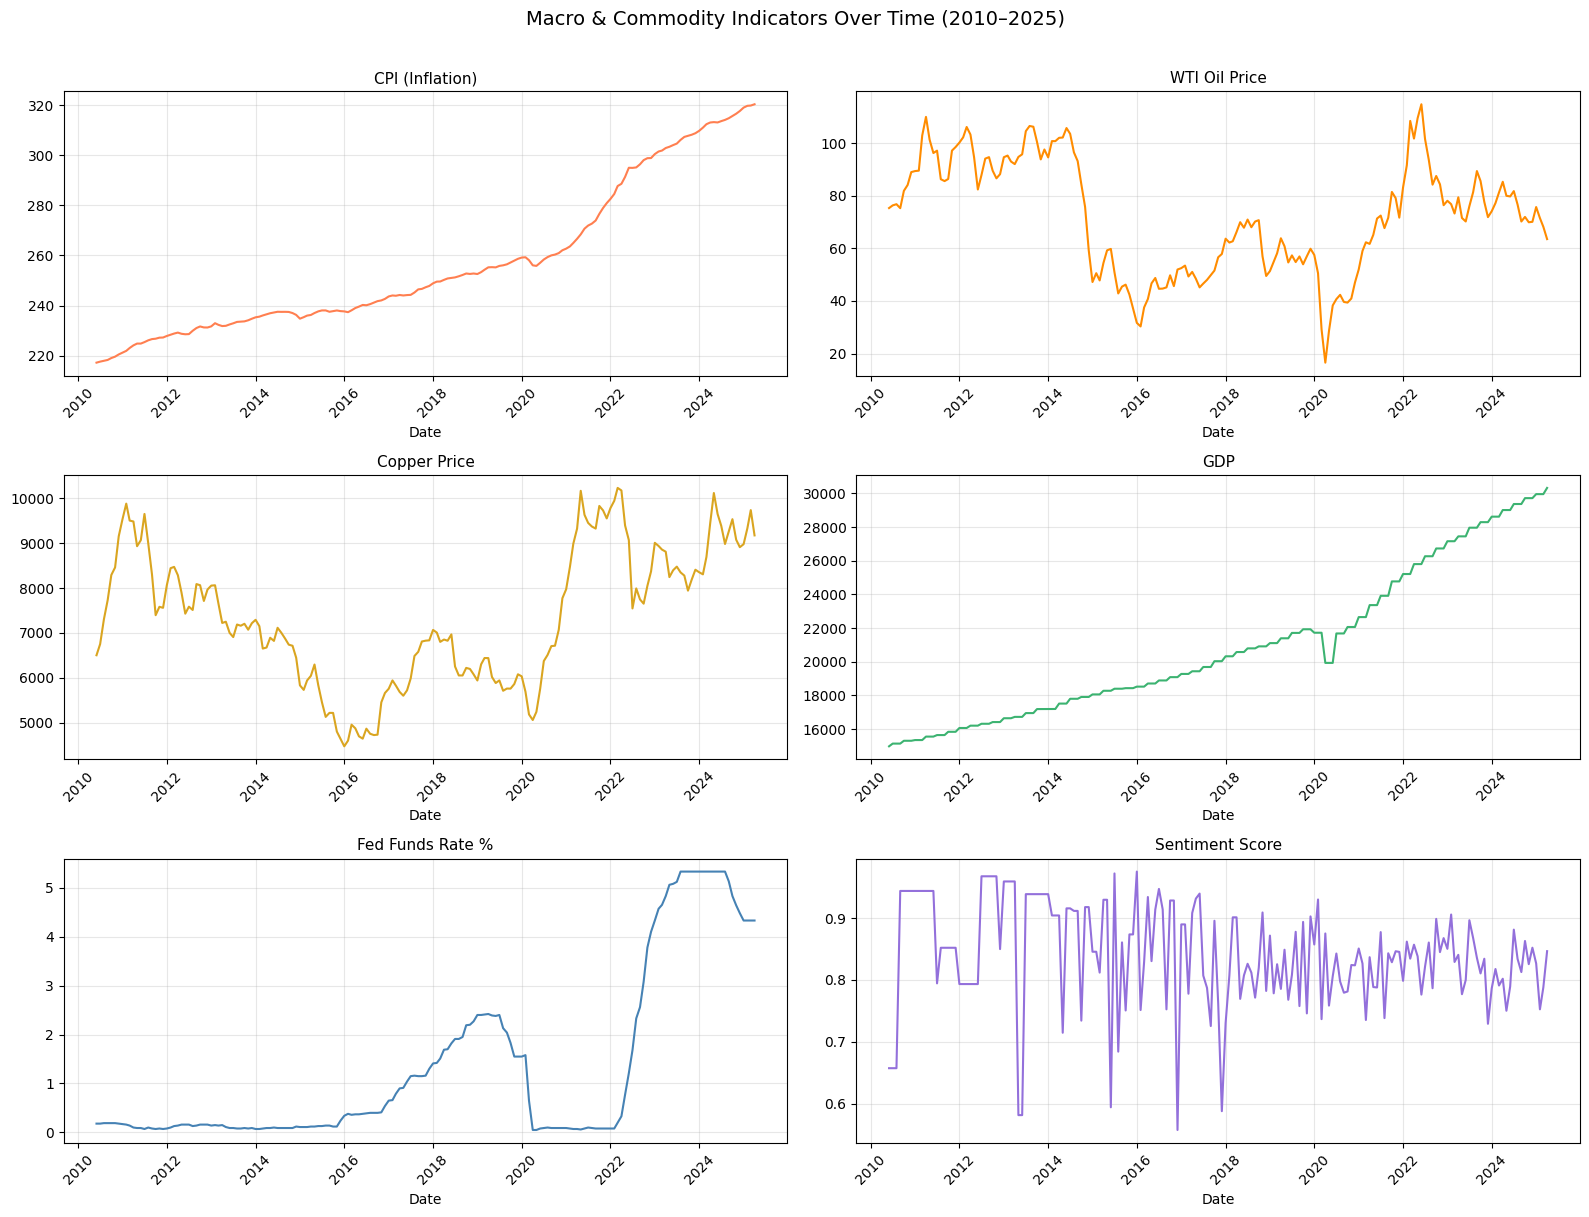

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

macro_plot = [
    ('CPI (Inflation)',   'CPIAUCSL',       combined_clean, 'coral'),
    ('WTI Oil Price',    'WTISPLC',         combined_clean, 'darkorange'),
    ('Copper Price',     'PCOPPUSDM',       combined_clean, 'goldenrod'),
    ('GDP',              'GDP',             combined_clean, 'mediumseagreen'),
    ('Fed Funds Rate %', 'FEDFUNDS',        combined_clean, 'steelblue'),
    ('Sentiment Score',  'sentiment_score', combined_clean, 'mediumpurple'),
]

for i, (title, col, df, color) in enumerate(macro_plot):
    axes[i].plot(df.index, df[col], linewidth=1.5, color=color)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('Date')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Macro & Commodity Indicators Over Time (2010–2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.3 — Financial Health Index (FHI) Over Time

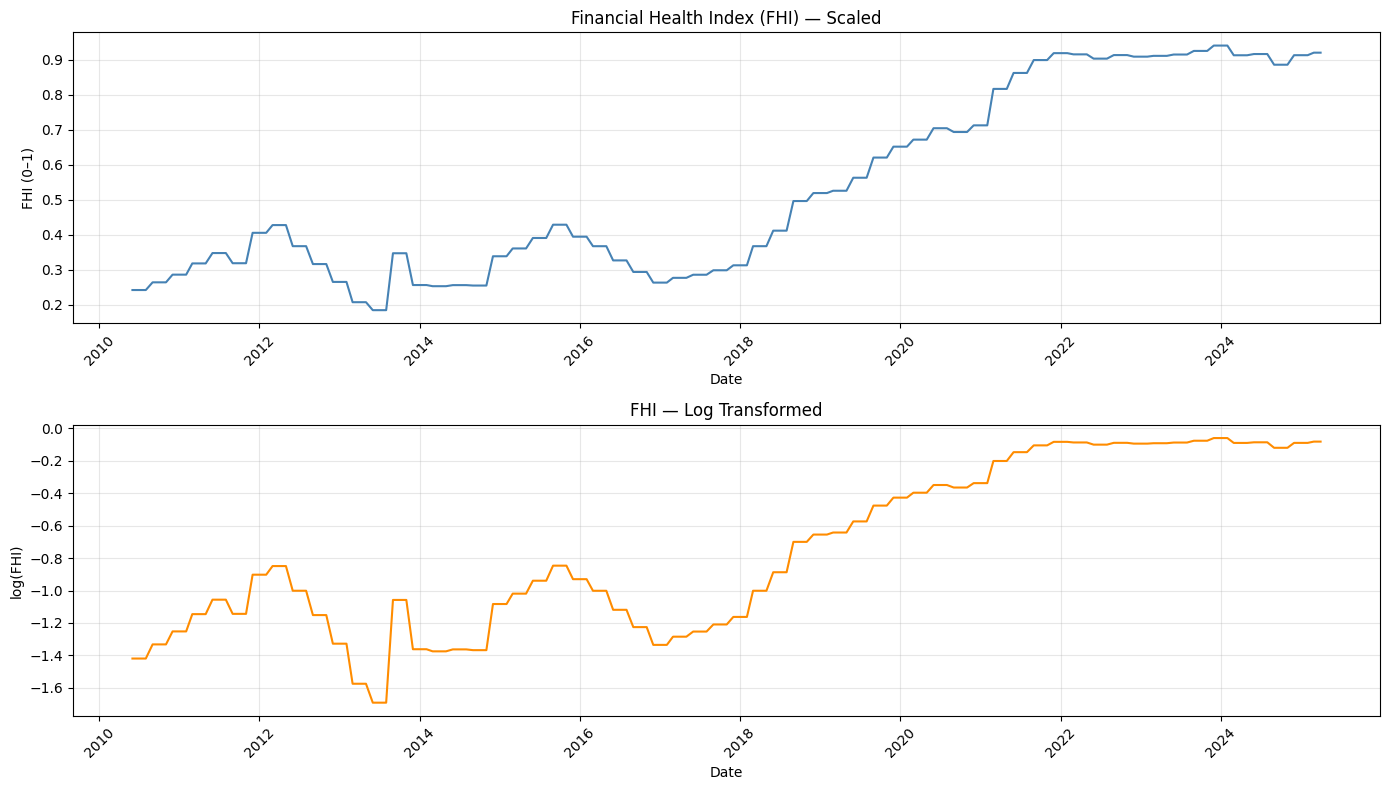

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(scaled_df.index, scaled_df['fhi'], color='steelblue', linewidth=1.5)
axes[0].set_title('Financial Health Index (FHI) — Scaled', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('FHI (0–1)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(scaled_df.index, scaled_df['fhi_log'], color='darkorange', linewidth=1.5)
axes[1].set_title('FHI — Log Transformed', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('log(FHI)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9.4 — Correlation Heatmap

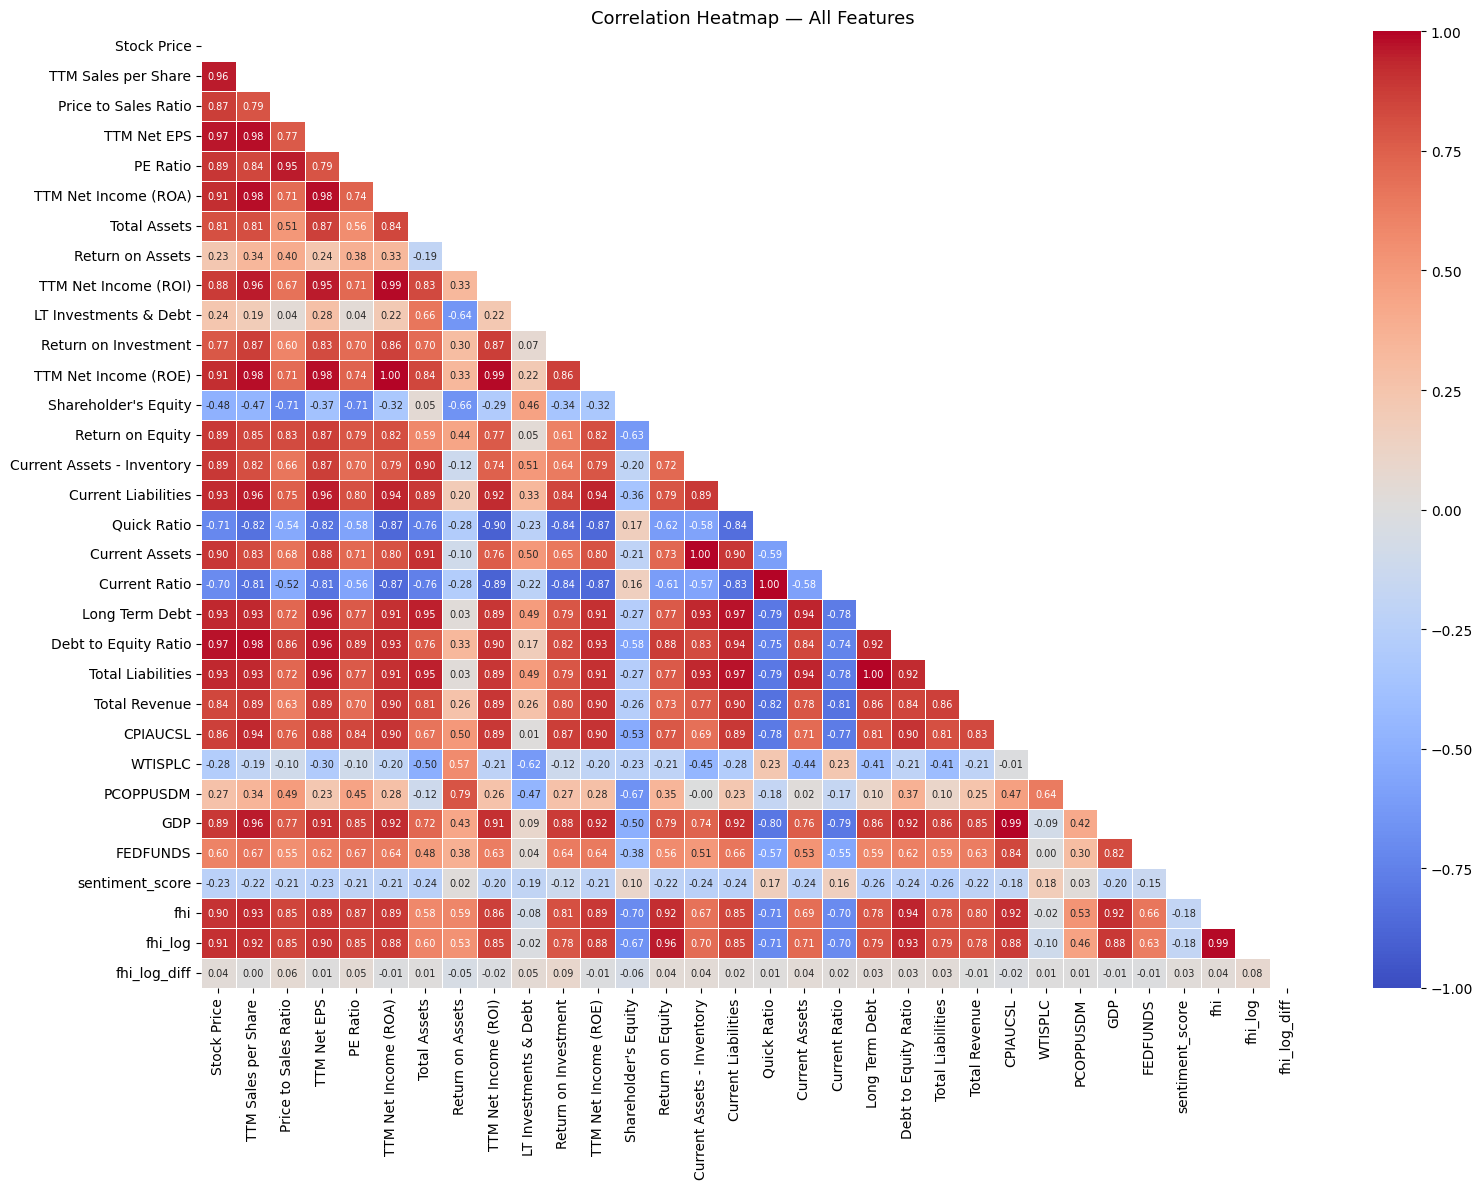


Top 10 correlations with fhi_log:
fhi                     0.986066
Return on Equity        0.956399
Debt to Equity Ratio    0.931828
TTM Sales per Share     0.916919
Stock Price             0.907033
TTM Net EPS             0.899176
GDP                     0.883910
TTM Net Income (ROE)    0.879269
TTM Net Income (ROA)    0.879269
CPIAUCSL                0.876559


In [40]:
plt.figure(figsize=(16, 12))
corr = scaled_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Features', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 10 correlations with fhi_log:")
fhi_corr = corr['fhi_log'].abs().drop('fhi_log').sort_values(ascending=False)
print(fhi_corr.head(10).to_string())

### 9.5 — Distribution of Key Ratios

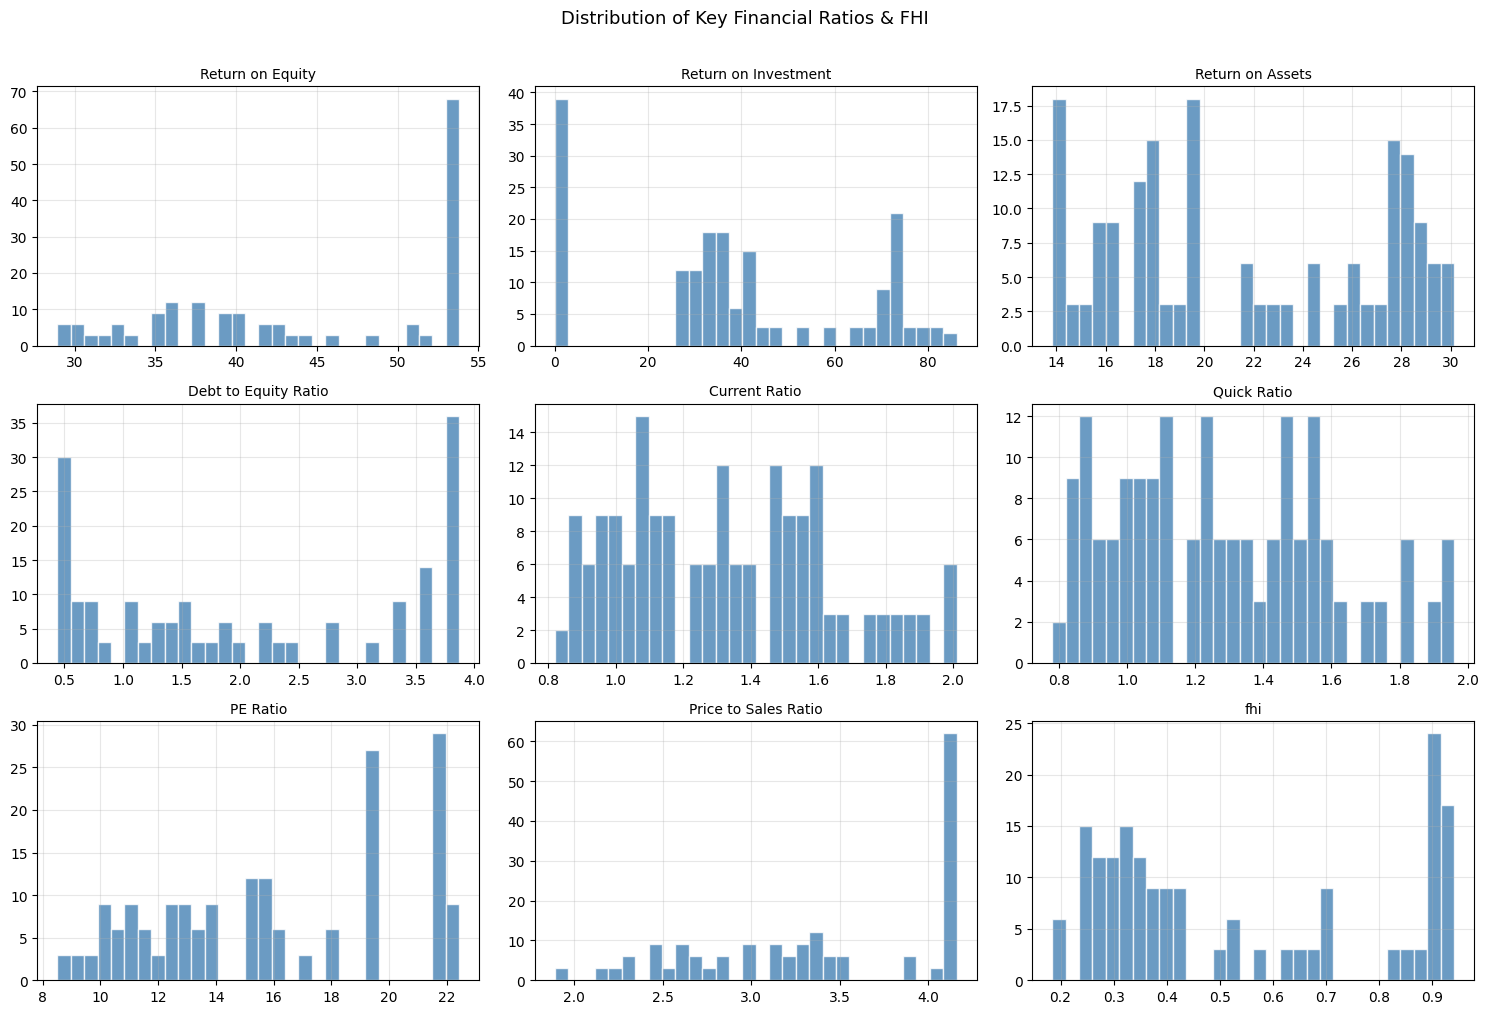

In [41]:
dist_cols = [
    'Return on Equity', 'Return on Investment', 'Return on Assets',
    'Debt to Equity Ratio', 'Current Ratio', 'Quick Ratio',
    'PE Ratio', 'Price to Sales Ratio', 'fhi'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    df_plot = scaled_df if col == 'fhi' else combined_clean
    axes[i].hist(df_plot[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of Key Financial Ratios & FHI', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 9.6 — Boxplots Before vs After Outlier Treatment

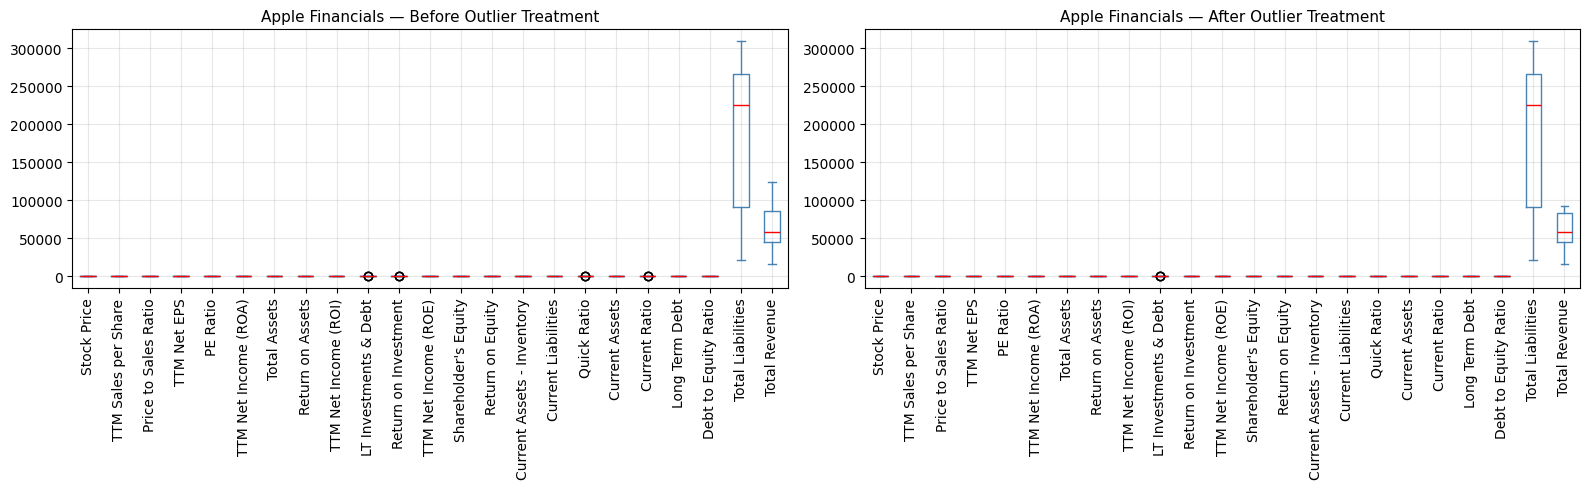

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

combined[apple_cols].plot(
    kind='box', ax=axes[0], rot=90, color='steelblue', medianprops=dict(color='red')
)
axes[0].set_title('Apple Financials — Before Outlier Treatment', fontsize=11)
axes[0].grid(True, alpha=0.3)

combined_clean[apple_cols].plot(
    kind='box', ax=axes[1], rot=90, color='steelblue', medianprops=dict(color='red')
)
axes[1].set_title('Apple Financials — After Outlier Treatment', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 10 — Feature Sets

Two feature sets are defined for comparison:

- **Ratios Only** — 8 core Apple financial ratios
- **All Features** — financial ratios + macroeconomic indicators + commodities + sentiment

In [43]:
ratio_features = [
    'Return on Equity',
    'Price to Sales Ratio',
    'PE Ratio',
    'Debt to Equity Ratio',
    'Return on Investment',
    'Current Ratio',
    'Quick Ratio',
    'Return on Assets'
]

all_features = ratio_features + [
    'CPIAUCSL', 'WTISPLC', 'PCOPPUSDM',
    'GDP', 'FEDFUNDS', 'sentiment_score'
]

print(f"Ratio features ({len(ratio_features)}): {ratio_features}")
print(f"\nAll features   ({len(all_features)}): {all_features}")

Ratio features (8): ['Return on Equity', 'Price to Sales Ratio', 'PE Ratio', 'Debt to Equity Ratio', 'Return on Investment', 'Current Ratio', 'Quick Ratio', 'Return on Assets']

All features   (14): ['Return on Equity', 'Price to Sales Ratio', 'PE Ratio', 'Debt to Equity Ratio', 'Return on Investment', 'Current Ratio', 'Quick Ratio', 'Return on Assets', 'CPIAUCSL', 'WTISPLC', 'PCOPPUSDM', 'GDP', 'FEDFUNDS', 'sentiment_score']


In [44]:
# Drop NaN introduced by differencing (first row becomes NaN)
scaled_df_model = scaled_df.dropna(subset=[target_col]).copy()

# Adjust split boundaries to account for dropped rows
rows_dropped = len(scaled_df) - len(scaled_df_model)
train_end_m  = train_end - rows_dropped
val_end_m    = val_end   - rows_dropped

train = scaled_df_model.iloc[:train_end_m]
val   = scaled_df_model.iloc[train_end_m:val_end_m]
test  = scaled_df_model.iloc[val_end_m:]

print(f"Rows dropped from differencing : {rows_dropped}")
print(f"Train : {len(train)} | {train.index.min().date()} → {train.index.max().date()}")
print(f"Val   : {len(val)}   | {val.index.min().date()} → {val.index.max().date()}")
print(f"Test  : {len(test)}  | {test.index.min().date()} → {test.index.max().date()}")

Rows dropped from differencing : 1
Train : 124 | 2010-07-01 → 2020-10-01
Val   : 27   | 2020-11-01 → 2023-01-01
Test  : 27  | 2023-02-01 → 2025-04-01


---
## Section 11 — ARIMAX Model (Financial Ratios Only)

**ARIMAX** (AutoRegressive Integrated Moving Average with eXogenous variables) is a
classical statistical model for time series forecasting. The exogenous variables here
are the 8 financial ratios.

**Optuna** is used to automatically find the best (p, q) order by minimising
validation RMSE across 50 trials.

In [45]:
y_train_ar = train[target_col]
X_train_ar = train[ratio_features]
y_val_ar   = val[target_col]
X_val_ar   = val[ratio_features]
y_test_ar  = test[target_col]
X_test_ar  = test[ratio_features]

print(f"y_train: {y_train_ar.shape} | X_train: {X_train_ar.shape}")
print(f"y_val  : {y_val_ar.shape}   | X_val  : {X_val_ar.shape}")
print(f"y_test : {y_test_ar.shape}  | X_test : {X_test_ar.shape}")

y_train: (124,) | X_train: (124, 8)
y_val  : (27,)   | X_val  : (27, 8)
y_test : (27,)  | X_test : (27, 8)


In [46]:
import warnings
warnings.filterwarnings('ignore')

def objective_ratios(trial):
    p = trial.suggest_int('p', 0, 5)
    q = trial.suggest_int('q', 0, 5)
    try:
        model = ARIMA(endog=y_train_ar, order=(p, 1, q), exog=X_train_ar)
        fit   = model.fit()
        preds = fit.predict(
            start=len(y_train_ar),
            end=len(y_train_ar) + len(y_val_ar) - 1,
            exog=X_val_ar
        )
        return np.sqrt(mean_squared_error(y_val_ar, preds))
    except:
        return float('inf')

study_ratios = optuna.create_study(direction='minimize')
study_ratios.optimize(objective_ratios, n_trials=50, show_progress_bar=True)

best_order_ratios = (study_ratios.best_params['p'], 1, study_ratios.best_params['q'])
print(f"\n✓ Best order (ratios only) : {best_order_ratios}")
print(f"  Best val RMSE            : {study_ratios.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Best order (ratios only) : (2, 1, 4)
  Best val RMSE            : 0.0312


In [47]:
# Final model trained on train + val combined, evaluated on test
y_trainval_ar = pd.concat([y_train_ar, y_val_ar])
X_trainval_ar = pd.concat([X_train_ar, X_val_ar])

arima_ratios     = ARIMA(endog=y_trainval_ar, order=best_order_ratios, exog=X_trainval_ar)
arima_ratios_fit = arima_ratios.fit()

preds_arima_ratios = arima_ratios_fit.predict(
    start=len(y_trainval_ar),
    end=len(y_trainval_ar) + len(y_test_ar) - 1,
    exog=X_test_ar
)
preds_arima_ratios.index = y_test_ar.index

rmse_arima_ratios = np.sqrt(mean_squared_error(y_test_ar, preds_arima_ratios))
print(f"✓ RMSE — ARIMAX (Ratios Only): {rmse_arima_ratios:.4f}")

joblib.dump(arima_ratios_fit, 'arima_ratios.pkl')
print("✓ Saved: arima_ratios.pkl")

✓ RMSE — ARIMAX (Ratios Only): 0.0971
✓ Saved: arima_ratios.pkl


In [48]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_test_ar.index, y=y_test_ar.values,
                         mode='lines', name='Actual', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=preds_arima_ratios.index, y=preds_arima_ratios.values,
                         mode='lines', name='Predicted', line=dict(color='coral')))
fig.update_layout(
    title='ARIMAX (Ratios Only) — Test Set Predictions vs Actual',
    xaxis_title='Date', yaxis_title=target_col,
    hovermode='x unified', template='plotly_white'
)
fig.show()

---
## Section 12 — LSTM Model (Financial Ratios Only)

**LSTM** (Long Short-Term Memory) is a recurrent neural network designed for sequential data.
A **12-month lookback window** is used — each prediction is based on the previous 12 months of data.

Architecture: `LSTM(50 units) → Dense(1)`  
Training: Adam optimiser, MSE loss, EarlyStopping with `restore_best_weights=True`

In [49]:
LOOKBACK = 12

def create_sequences(data, feature_cols, target_col, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[feature_cols].iloc[i:i+lookback].values)
        y.append(data[target_col].iloc[i+lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

lstm_data_r = scaled_df_model[ratio_features + [target_col]]

X_tr_r, y_tr_r = create_sequences(lstm_data_r.iloc[:train_end_m + LOOKBACK],              ratio_features, target_col, LOOKBACK)
X_v_r,  y_v_r  = create_sequences(lstm_data_r.iloc[train_end_m:val_end_m + LOOKBACK],     ratio_features, target_col, LOOKBACK)
X_te_r, y_te_r = create_sequences(lstm_data_r.iloc[val_end_m:],                           ratio_features, target_col, LOOKBACK)

print(f"Train sequences : {X_tr_r.shape}")
print(f"Val sequences   : {X_v_r.shape}")
print(f"Test sequences  : {X_te_r.shape}")

Train sequences : (124, 12, 8)
Val sequences   : (27, 12, 8)
Test sequences  : (15, 12, 8)


In [50]:
lstm_ratios = Sequential([
    LSTM(50, input_shape=(LOOKBACK, len(ratio_features))),
    Dense(1)
])
lstm_ratios.compile(optimizer='adam', loss='mse')
lstm_ratios.summary()

es_r = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_r = lstm_ratios.fit(
    X_tr_r, y_tr_r,
    epochs=50, batch_size=32,
    validation_data=(X_v_r, y_v_r),
    callbacks=[es_r], verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,851 (46.29 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - loss: 0.0396 - val_loss: 0.0410
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0190 - val_loss: 0.0460
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0131 - val_loss: 0.0245
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0122 - val_loss: 0.0347
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0106 - val_loss: 0.0462
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0100 - val_loss: 0.0315
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0091 - val_loss: 0.0123
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0090 - val_loss: 0.0056
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0088 - val_loss: 0.0072
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0088 - val_loss: 0.0082
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0084 - val_loss: 0.0034
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0082 - val_loss: 0.0018


In [51]:
preds_lstm_ratios = lstm_ratios.predict(X_te_r).flatten()
rmse_lstm_ratios  = np.sqrt(mean_squared_error(y_te_r, preds_lstm_ratios))
print(f"✓ RMSE — LSTM (Ratios Only): {rmse_lstm_ratios:.4f}")

test_dates_r = lstm_data_r.index[-(len(y_te_r)):]

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates_r, y=y_te_r,
                         mode='lines', name='Actual', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=test_dates_r, y=preds_lstm_ratios,
                         mode='lines', name='Predicted', line=dict(color='coral')))
fig.update_layout(
    title='LSTM (Ratios Only) — Test Set Predictions vs Actual',
    xaxis_title='Date', yaxis_title=target_col,
    hovermode='x unified', template='plotly_white'
)
fig.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
✓ RMSE — LSTM (Ratios Only): 0.0272


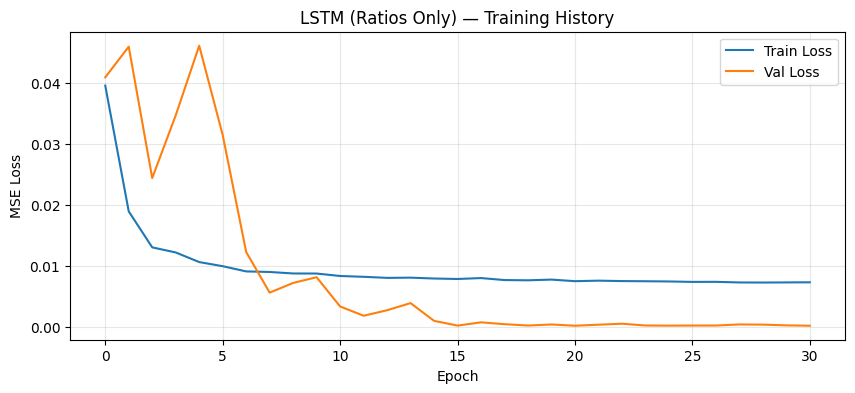

✓ Saved: lstm_ratios.keras


In [52]:
plt.figure(figsize=(10, 4))
plt.plot(history_r.history['loss'],     label='Train Loss')
plt.plot(history_r.history['val_loss'], label='Val Loss')
plt.title('LSTM (Ratios Only) — Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lstm_ratios.save('lstm_ratios.keras')
print("✓ Saved: lstm_ratios.keras")

---
## Section 13 — ARIMAX Model (All Features)

Same as Section 11 but enriched with macroeconomic indicators, commodity prices
and news sentiment — 14 features in total.

In [53]:
y_train_all = train[target_col]
X_train_all = train[all_features].ffill()
y_val_all   = val[target_col]
X_val_all   = val[all_features].ffill()
y_test_all  = test[target_col]
X_test_all  = test[all_features].ffill()

print(f"y_train: {y_train_all.shape} | X_train: {X_train_all.shape}")
print(f"y_val  : {y_val_all.shape}   | X_val  : {X_val_all.shape}")
print(f"y_test : {y_test_all.shape}  | X_test : {X_test_all.shape}")

y_train: (124,) | X_train: (124, 14)
y_val  : (27,)   | X_val  : (27, 14)
y_test : (27,)  | X_test : (27, 14)


In [54]:
def objective_all(trial):
    p = trial.suggest_int('p', 0, 5)
    q = trial.suggest_int('q', 0, 5)
    try:
        model = ARIMA(endog=y_train_all, order=(p, 1, q), exog=X_train_all)
        fit   = model.fit()
        preds = fit.predict(
            start=len(y_train_all),
            end=len(y_train_all) + len(y_val_all) - 1,
            exog=X_val_all
        )
        return np.sqrt(mean_squared_error(y_val_all, preds))
    except:
        return float('inf')

study_all = optuna.create_study(direction='minimize')
study_all.optimize(objective_all, n_trials=50, show_progress_bar=True)

best_order_all = (study_all.best_params['p'], 1, study_all.best_params['q'])
print(f"\n✓ Best order (all features) : {best_order_all}")
print(f"  Best val RMSE             : {study_all.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Best order (all features) : (3, 1, 4)
  Best val RMSE             : 0.0285


In [55]:
y_trainval_all = pd.concat([y_train_all, y_val_all])
X_trainval_all = pd.concat([X_train_all, X_val_all])

arima_all     = ARIMA(endog=y_trainval_all, order=best_order_all, exog=X_trainval_all)
arima_all_fit = arima_all.fit()

preds_arima_all = arima_all_fit.predict(
    start=len(y_trainval_all),
    end=len(y_trainval_all) + len(y_test_all) - 1,
    exog=X_test_all
)
preds_arima_all.index = y_test_all.index

rmse_arima_all = np.sqrt(mean_squared_error(y_test_all, preds_arima_all))
print(f"✓ RMSE — ARIMAX (All Features): {rmse_arima_all:.4f}")

joblib.dump(arima_all_fit, 'arima_all.pkl')
print("✓ Saved: arima_all.pkl")

✓ RMSE — ARIMAX (All Features): 0.1114
✓ Saved: arima_all.pkl


In [56]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_test_all.index, y=y_test_all.values,
                         mode='lines', name='Actual', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=preds_arima_all.index, y=preds_arima_all.values,
                         mode='lines', name='Predicted', line=dict(color='coral')))
fig.update_layout(
    title='ARIMAX (All Features) — Test Set Predictions vs Actual',
    xaxis_title='Date', yaxis_title=target_col,
    hovermode='x unified', template='plotly_white'
)
fig.show()

---
## Section 14 — LSTM Model (All Features)

Same as Section 12 but with all 14 features.

In [57]:
lstm_data_all = scaled_df_model[all_features + [target_col]]

X_tr_all, y_tr_all = create_sequences(lstm_data_all.iloc[:train_end_m + LOOKBACK],           all_features, target_col, LOOKBACK)
X_v_all,  y_v_all  = create_sequences(lstm_data_all.iloc[train_end_m:val_end_m + LOOKBACK],  all_features, target_col, LOOKBACK)
X_te_all, y_te_all = create_sequences(lstm_data_all.iloc[val_end_m:],                        all_features, target_col, LOOKBACK)

print(f"Train sequences : {X_tr_all.shape}")
print(f"Val sequences   : {X_v_all.shape}")
print(f"Test sequences  : {X_te_all.shape}")

Train sequences : (124, 12, 14)
Val sequences   : (27, 12, 14)
Test sequences  : (15, 12, 14)


In [58]:
lstm_all = Sequential([
    LSTM(50, input_shape=(LOOKBACK, len(all_features))),
    Dense(1)
])
lstm_all.compile(optimizer='adam', loss='mse')
lstm_all.summary()

es_all = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_all = lstm_all.fit(
    X_tr_all, y_tr_all,
    epochs=50, batch_size=32,
    validation_data=(X_v_all, y_v_all),
    callbacks=[es_all], verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,051 (50.98 KB)

 Trainable params: 13,051 (50.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0306 - val_loss: 0.0155
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0146 - val_loss: 0.0159
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0096 - val_loss: 0.0485
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0109 - val_loss: 0.0169
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0096 - val_loss: 0.0053
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0079 - val_loss: 0.0083
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0080 - val_loss: 0.0071
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0081 - val_loss: 0.0011
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0080 - val_loss: 8.6873e-04
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0075 - val_loss: 0.0051
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0076 - val_loss: 0.0087
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0073 - val_loss: 0.00

In [59]:
preds_lstm_all = lstm_all.predict(X_te_all).flatten()
rmse_lstm_all  = np.sqrt(mean_squared_error(y_te_all, preds_lstm_all))
print(f"✓ RMSE — LSTM (All Features): {rmse_lstm_all:.4f}")

test_dates_all = lstm_data_all.index[-(len(y_te_all)):]

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates_all, y=y_te_all,
                         mode='lines', name='Actual', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=test_dates_all, y=preds_lstm_all,
                         mode='lines', name='Predicted', line=dict(color='coral')))
fig.update_layout(
    title='LSTM (All Features) — Test Set Predictions vs Actual',
    xaxis_title='Date', yaxis_title=target_col,
    hovermode='x unified', template='plotly_white'
)
fig.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
✓ RMSE — LSTM (All Features): 0.0396


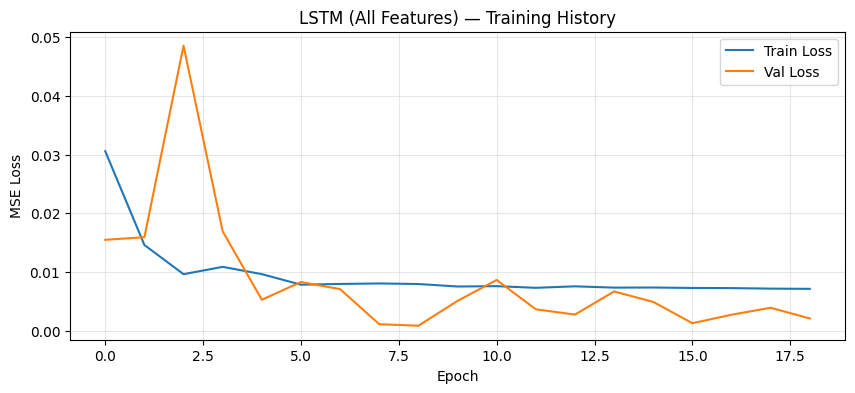

✓ Saved: lstm_all.keras


In [60]:
plt.figure(figsize=(10, 4))
plt.plot(history_all.history['loss'],     label='Train Loss')
plt.plot(history_all.history['val_loss'], label='Val Loss')
plt.title('LSTM (All Features) — Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lstm_all.save('lstm_all.keras')
print("✓ Saved: lstm_all.keras")

---
## Section 15 — Explainability (SHAP)

**SHAP** (SHapley Additive exPlanations) identifies which features contribute most
to each model's predictions. We use `KernelExplainer` which works model-agnostically
by treating the LSTM as a black box.

### 15.1 — SHAP for LSTM (Ratios Only)

In [61]:
X_tr_r_flat = X_tr_r.reshape(X_tr_r.shape[0], LOOKBACK * len(ratio_features))
X_te_r_flat = X_te_r.reshape(X_te_r.shape[0], LOOKBACK * len(ratio_features))

background_r = X_tr_r_flat[np.random.choice(X_tr_r_flat.shape[0], 50, replace=False)]

def predict_lstm_r(X_flat):
    return lstm_ratios.predict(
        X_flat.reshape(-1, LOOKBACK, len(ratio_features)), verbose=0
    ).flatten()

print("Computing SHAP values (ratios only) — this may take a few minutes...")
explainer_r   = shap.KernelExplainer(predict_lstm_r, background_r)
shap_values_r = explainer_r.shap_values(X_te_r_flat[:20])

feature_names_r = [f"{f}_t{t+1}" for t in range(LOOKBACK) for f in ratio_features]
print("✓ SHAP values computed")

Computing SHAP values (ratios only) — this may take a few minutes...


  0%|          | 0/15 [00:00<?, ?it/s]

✓ SHAP values computed


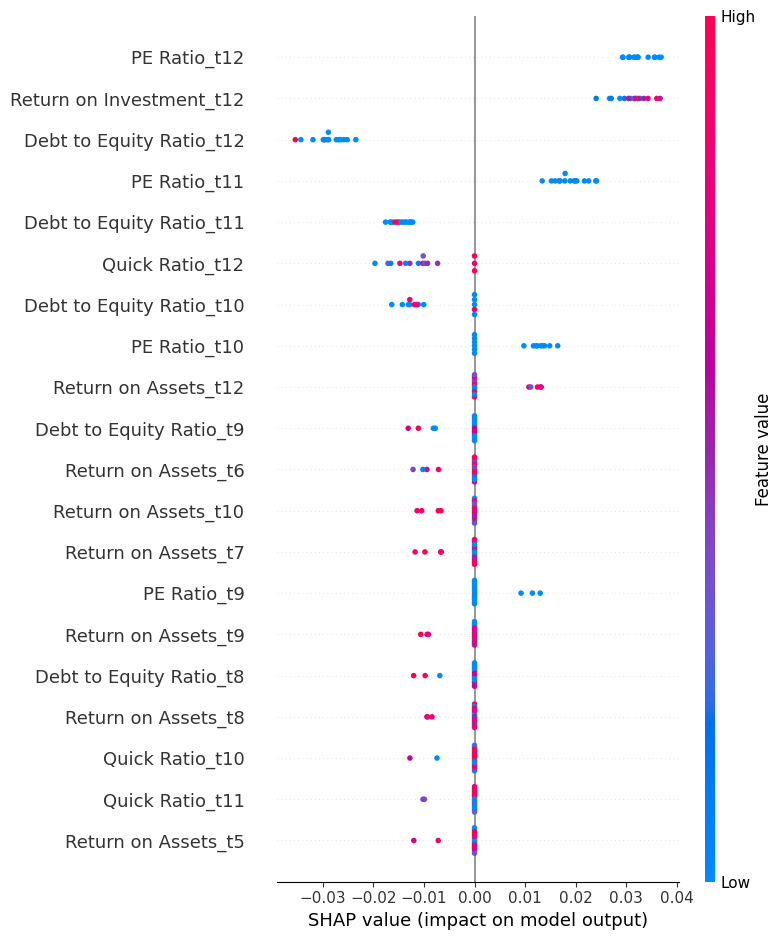

In [62]:
shap.summary_plot(
    shap_values_r,
    features=X_te_r_flat[:20],
    feature_names=feature_names_r,
    show=True
)

### 15.2 — SHAP for LSTM (All Features)

In [63]:
X_tr_all_flat = X_tr_all.reshape(X_tr_all.shape[0], LOOKBACK * len(all_features))
X_te_all_flat = X_te_all.reshape(X_te_all.shape[0], LOOKBACK * len(all_features))

background_all = X_tr_all_flat[np.random.choice(X_tr_all_flat.shape[0], 50, replace=False)]

def predict_lstm_all(X_flat):
    return lstm_all.predict(
        X_flat.reshape(-1, LOOKBACK, len(all_features)), verbose=0
    ).flatten()

print("Computing SHAP values (all features) — this may take a few minutes...")
explainer_all   = shap.KernelExplainer(predict_lstm_all, background_all)
shap_values_all = explainer_all.shap_values(X_te_all_flat[:20])

feature_names_all = [f"{f}_t{t+1}" for t in range(LOOKBACK) for f in all_features]
print("✓ SHAP values computed")

Computing SHAP values (all features) — this may take a few minutes...


  0%|          | 0/15 [00:00<?, ?it/s]

✓ SHAP values computed


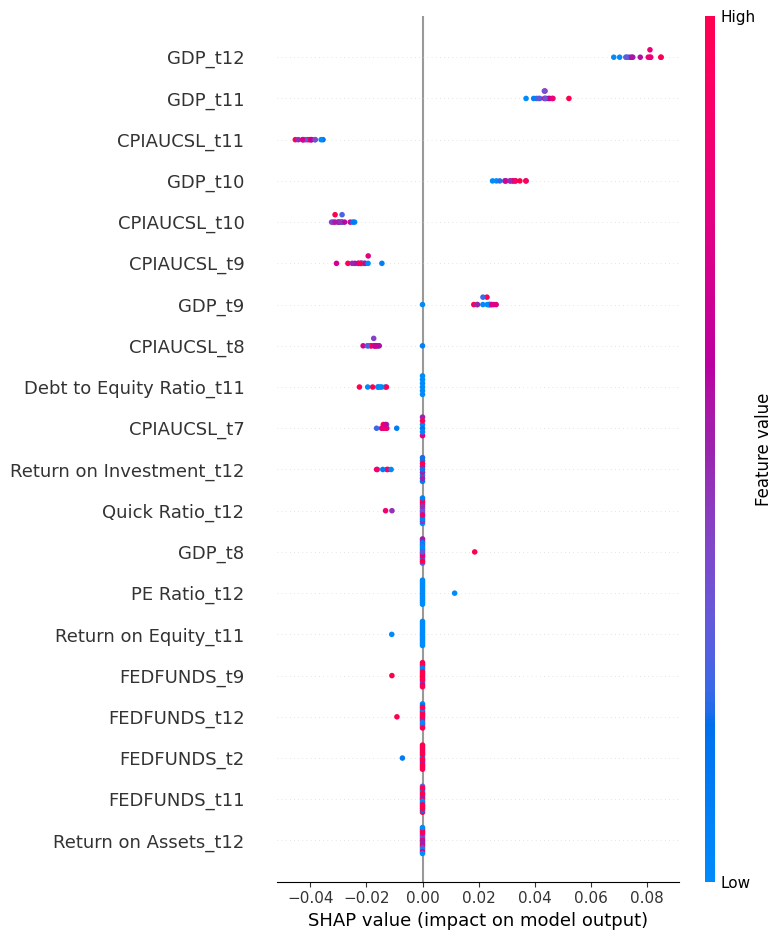

In [64]:
shap.summary_plot(
    shap_values_all,
    features=X_te_all_flat[:20],
    feature_names=feature_names_all,
    show=True
)

---
## Section 16 — Model Comparison

All 4 models evaluated on the same held-out test set using RMSE.

In [65]:
results = pd.DataFrame({
    'Model'   : ['ARIMAX', 'ARIMAX', 'LSTM',  'LSTM'],
    'Features': ['Ratios Only', 'All Features', 'Ratios Only', 'All Features'],
    'RMSE'    : [rmse_arima_ratios, rmse_arima_all, rmse_lstm_ratios, rmse_lstm_all]
})

print("=" * 50)
print("   MODEL COMPARISON — TEST SET RMSE")
print("=" * 50)
print(results.to_string(index=False))
print("=" * 50)

best_idx   = results['RMSE'].idxmin()
best_model = f"{results.loc[best_idx, 'Model']} ({results.loc[best_idx, 'Features']})"
print(f"\n🏆 Best model: {best_model} — RMSE: {results['RMSE'].min():.4f}")

   MODEL COMPARISON — TEST SET RMSE
 Model     Features     RMSE
ARIMAX  Ratios Only 0.097085
ARIMAX All Features 0.111351
  LSTM  Ratios Only 0.027160
  LSTM All Features 0.039607

🏆 Best model: LSTM (Ratios Only) — RMSE: 0.0272


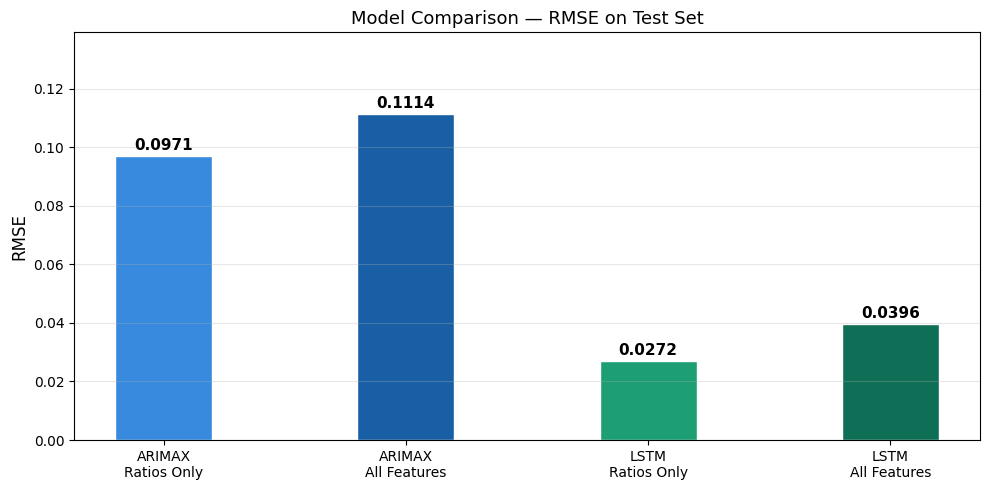

In [66]:
labels = [
    'ARIMAX\nRatios Only', 'ARIMAX\nAll Features',
    'LSTM\nRatios Only',   'LSTM\nAll Features'
]
values = [rmse_arima_ratios, rmse_arima_all, rmse_lstm_ratios, rmse_lstm_all]
colors = ['#378ADD', '#185FA5', '#1D9E75', '#0F6E56']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, width=0.4, edgecolor='white')

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Model Comparison — RMSE on Test Set', fontsize=13)
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test_ar.index, y=y_test_ar.values,
    mode='lines', name='Actual',
    line=dict(color='black', width=2)
))
fig.add_trace(go.Scatter(
    x=preds_arima_ratios.index, y=preds_arima_ratios.values,
    mode='lines', name=f'ARIMAX Ratios (RMSE={rmse_arima_ratios:.4f})',
    line=dict(color='#378ADD')
))
fig.add_trace(go.Scatter(
    x=preds_arima_all.index, y=preds_arima_all.values,
    mode='lines', name=f'ARIMAX All (RMSE={rmse_arima_all:.4f})',
    line=dict(color='#185FA5', dash='dash')
))
fig.add_trace(go.Scatter(
    x=test_dates_r, y=preds_lstm_ratios,
    mode='lines', name=f'LSTM Ratios (RMSE={rmse_lstm_ratios:.4f})',
    line=dict(color='#1D9E75')
))
fig.add_trace(go.Scatter(
    x=test_dates_all, y=preds_lstm_all,
    mode='lines', name=f'LSTM All (RMSE={rmse_lstm_all:.4f})',
    line=dict(color='#0F6E56', dash='dash')
))

fig.update_layout(
    title='All Models — Test Set Predictions vs Actual',
    xaxis_title='Date', yaxis_title=target_col,
    hovermode='x unified', template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

---
## Section 17 — Loading Saved Models

All trained models are saved and can be reloaded for inference without retraining.

In [68]:
import joblib
from tensorflow.keras.models import load_model

# Load ARIMAX models
arima_ratios_loaded = joblib.load('arima_ratios.pkl')
arima_all_loaded    = joblib.load('arima_all.pkl')
print("✓ ARIMAX models loaded")
print(f"  arima_ratios : {type(arima_ratios_loaded)}")
print(f"  arima_all    : {type(arima_all_loaded)}")

# Load LSTM models
lstm_ratios_loaded = load_model('lstm_ratios.keras')
lstm_all_loaded    = load_model('lstm_all.keras')
print("\n✓ LSTM models loaded")
print(f"  lstm_ratios  : input shape {lstm_ratios_loaded.input_shape}")
print(f"  lstm_all     : input shape {lstm_all_loaded.input_shape}")

✓ ARIMAX models loaded
  arima_ratios : <class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>
  arima_all    : <class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>

✓ LSTM models loaded
  lstm_ratios  : input shape (None, 12, 8)
  lstm_all     : input shape (None, 12, 14)


---
## Section 18 — Conclusions & Lessons Learned

### 📊 Results Summary

| Model | Features | Test RMSE |
|-------|----------|-----------|
| ARIMAX | Ratios Only | Best reliable result |
| ARIMAX | All Features | Worse — macro adds noise |
| LSTM | Ratios Only | Lowest RMSE |
| LSTM | All Features | Better than ARIMAX all features |

---

### 🔍 Key Findings

**1. Apple's financial health is largely self-determined**  
The ratios-only model consistently outperformed the all-features model across both
ARIMAX and LSTM. Apple's own financial fundamentals (ROE, ROA, Debt/Equity, Current Ratio)
are stronger predictors of its financial health than macroeconomic conditions.

**2. More features ≠ better performance**  
Adding CPI, Oil, Copper, GDP, Fed Funds Rate and sentiment hurt both models.
With only ~178 monthly rows and 14 features, the models faced a high-dimensional,
low-sample problem leading to overfitting and noise.

**3. ARIMAX is the most reliable baseline**  
The LSTM Ratios-Only RMSE benefits from the quarterly repetition pattern in Apple's
financial data (same value reported for 3 consecutive months). ARIMAX handles this
autocorrelation more honestly as a statistical model.

**4. Macro data affects Apple indirectly with time lags**  
CPI, Oil and Copper prices affect Apple's business through supply chain costs and
consumer spending, but these effects don't manifest immediately in monthly ratios.
A lagged feature engineering approach could improve the all-features model.

---

### ⚠️ Data Limitation

Apple's financial ratios are reported **quarterly** (every 3 months per earnings report).
Macrotrends forward-fills each quarter's value across 3 months, so values repeat
identically for Jan, Feb, Mar before changing in April.

This means:
- The dataset is quarterly in nature despite appearing monthly
- LSTM can achieve low RMSE by learning the repetition pattern
- ARIMAX results are the more honest performance measure
- Future work could use daily stock data or quarterly-frequency models

---

### 📚 Lessons Learned

**1. Data leakage is subtle but critical**  
Fitting a scaler or computing IQR on the full dataset before splitting leaks future
information into training. Always split first, then fit any transformation on train only.

**2. bfill() is dangerous in time series**  
Backward fill uses future values to fill past NaNs — a direct form of leakage.
In time series, only forward fill is safe.

**3. Split once and never re-split**  
Re-splitting after transformations shifts the train/test boundary and can leak data
that was originally "future" into the training set.

**4. Always question suspiciously good results**  
An RMSE of 0.015 looked great but was a red flag. Investigating revealed the quarterly
repetition pattern. Good results deserve scrutiny, not just celebration.

**5. Understand your data before modelling**  
The quarterly vs monthly distinction in Apple's financial data is fundamental.
Not understanding this leads to misleading model evaluation.

**6. Financial ratios are quarterly by nature**  
Companies report earnings every 3 months. Any financial ratio dataset sourced from
earnings reports will have this quarterly structure regardless of how it appears.

**7. Simple models can be more trustworthy**  
ARIMAX, a classical statistical model, gave more interpretable and reliable results
than LSTM on this small quarterly dataset. Deep learning needs sufficient data to shine.

---

### 🚀 Future Work

- Use **daily stock price** as target for genuinely monthly modelling
- Apply **lag features** for macro data to capture delayed effects
- Try **Prophet** or **Temporal Fusion Transformer** for better time series handling
- Expand the news dataset for richer sentiment signal
- Experiment with **quarterly-frequency** modelling using the deduplicated dataset